In [1]:
# ============================================
# Step 1: Imports and device setup
# ============================================
import os
from pathlib import Path
from time import time
from typing import Tuple, Dict

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")
print(f"Using device: {device}")
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())


# ============================================
# Step 2: Load and preprocess data
# ============================================

file_path = "output-tracer-release-rand-wind-365-_2025-11-18.nc"
ds = xr.open_dataset(file_path, chunks={'time': 10})

# Extract and align variables on (time, y, x)
u = ds['u'].squeeze('zC').rename({'xF': 'x', 'yC': 'y'})  # (time, y, x)
v = ds['v'].squeeze('zC').rename({'xC': 'x', 'yF': 'y'})  # (time, y, x)
c = ds['c'].squeeze('zC').rename({'xC': 'x', 'yC': 'y'})  # (time, y, x)

# Merge into single Dataset and fill NaNs
ds_merge = xr.merge([
    u.to_dataset(name='u'),
    v.to_dataset(name='v'),
    c.to_dataset(name='c'),
]).fillna(0.0)

# Input at t, target at t+1 (hourly snapshots)
ds_input  = ds_merge.isel(time=slice(0, -1))    # t0 ... t_{N-2}
ds_target = ds_merge.isel(time=slice(1, None))  # t1 ... t_{N-1}

# Grid spacing in meters
x = ds["xC"].values
y = ds["yC"].values
dx = float(x[1] - x[0])
dy = float(y[1] - y[0])
print("dx, dy (m):", dx, dy)

# --------------------------------------------
# Helper: convert xarray -> torch tensor
# --------------------------------------------
def to_tensor(ds_var, var_list):
    """
    ds_var: xarray.Dataset with dims (time, y, x)
    var_list: list of variable names to stack
    returns tensor of shape (time, n_vars, y, x)
    """
    arr = ds_var[var_list].to_array().values  # (n_vars, time, y, x)
    t = torch.tensor(arr, dtype=torch.float32)  # (n_vars, time, y, x)
    return t.permute(1, 0, 2, 3).to(device)    # (time, n_vars, y, x)

forcing_vars    = ['u', 'v']
prognostic_vars = ['c']
output_vars     = prognostic_vars

forcing_tensor    = to_tensor(ds_input, forcing_vars)      # (Nt-1, 2, H, W)
prognostic_tensor = to_tensor(ds_input, prognostic_vars)   # (Nt-1, 1, H, W)
target_tensor     = to_tensor(ds_target, output_vars)      # (Nt-1, 1, H, W)

print("Forcing shape:",    forcing_tensor.shape)
print("Prognostic shape:", prognostic_tensor.shape)
print("Target shape:",     target_tensor.shape)

# --------------------------------------------
# Normalization
# --------------------------------------------
def normalize(tensor):
    mean = tensor.mean()
    std  = tensor.std()
    return (tensor - mean) / std, mean, std

forcing_tensor, f_mean, f_std    = normalize(forcing_tensor)
prognostic_tensor, p_mean, p_std = normalize(prognostic_tensor)
target_tensor = (target_tensor - p_mean) / p_std  # normalize with same stats

print("NaNs in forcing:",  torch.isnan(forcing_tensor).sum().item())
print("NaNs in target:",   torch.isnan(target_tensor).sum().item())

# --------------------------------------------
# Train / val / test split (along time axis)
# --------------------------------------------
Nt = forcing_tensor.shape[0]
n_train = int(0.7 * Nt)
n_val   = int(0.85 * Nt)
n_test  = Nt - n_val

forcing_train    = forcing_tensor[:n_train]
prognostic_train = prognostic_tensor[:n_train]
target_train     = target_tensor[:n_train]

forcing_val    = forcing_tensor[n_train:n_val]
prognostic_val = prognostic_tensor[n_train:n_val]
target_val     = target_tensor[n_train:n_val]

forcing_test    = forcing_tensor[n_val:]
prognostic_test = prognostic_tensor[n_val:]
target_test     = target_tensor[n_val:]

print(f"Train/Val/Test sizes: {n_train}, {n_val-n_train}, {n_test}")


# ============================================
# Step 3: Physics loss
# ============================================
def compute_physics_loss(forcing, prognostic, model_output, dx, dy, D=0.0):
    """
    Compute PDE residual from 2D advection–diffusion equation.
    All inputs: (batch, 1 or 2, H, W) on normalized fields.
    """
    u = forcing[:, 0]  # (B, H, W)
    v = forcing[:, 1]  # (B, H, W)
    c_t   = prognostic[:, 0]     # at time t
    c_tp1 = model_output[:, 0]   # predicted at t+1

    # time step in "1 timestep" units (consistent with training)
    dt = 1.0

    dc_dt = (c_tp1 - c_t) / dt

    # central differences with periodic boundary in x,y
    dc_dx = (torch.roll(c_t, -1, dims=2) - torch.roll(c_t, 1, dims=2)) / (2 * dx)
    dc_dy = (torch.roll(c_t, -1, dims=1) - torch.roll(c_t, 1, dims=1)) / (2 * dy)

    advection = u * dc_dx + v * dc_dy

    if D > 0:
        d2c_dx2 = (torch.roll(c_t, -1, 2) - 2 * c_t + torch.roll(c_t, 1, 2)) / (dx ** 2)
        d2c_dy2 = (torch.roll(c_t, -1, 1) - 2 * c_t + torch.roll(c_t, 1, 1)) / (dy ** 2)
        diffusion = D * (d2c_dx2 + d2c_dy2)
    else:
        diffusion = 0.0

    residual = dc_dt + advection - diffusion
    return torch.mean(residual ** 2)


# ============================================
# Step 4: PINN model
# ============================================
class ConvPINN(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(n_inputs, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, n_outputs, kernel_size=3, padding=1)
        )

    def forward(self, forcing, prognostic, training=True, num_future_steps=1):
        if training:
            # Single-step mapping: [B,2,H,W] + [B,1,H,W] -> [B,1,H,W]
            x = torch.cat([forcing, prognostic], dim=1)
            return self.model(x)
        else:
            # Autoregressive rollout: forcing has shape [B, T, 2, H, W]
            predictions = []
            current_state = prognostic  # [B,1,H,W]

            for t in range(num_future_steps):
                f_t = forcing[:, t]                     # [B,2,H,W]
                x   = torch.cat([f_t, current_state], dim=1)  # [B,3,H,W]
                current_state = self.model(x)          # [B,1,H,W]
                predictions.append(current_state)

            # For B=1, returning [T,1,H,W] is convenient
            return torch.cat(predictions, dim=0)       # [T,1,H,W] when B=1


# ============================================
# Step 5: Test metrics (single-step, global stats)
# ============================================
def compute_test_metrics_timeseries(model, forcing, prognostic, target,
                                    batch_size=4):
    """
    Compute:
      - MSE, RMSE (normalized)
      - Bias = mean(pred - truth) over all points
      - Global correlation over all points
      - Std of truth and prediction
      - Pattern correlation time series across test times
    """
    model.eval()
    num_steps = forcing.shape[0]

    total_mse_sum   = 0.0
    total_samples   = 0
    all_corrs       = []
    all_indices     = []  # index within test segment

    # for bias and global stats
    bias_sum   = 0.0
    n_points   = 0
    sum_t      = 0.0
    sum_p      = 0.0
    sum_t2     = 0.0
    sum_p2     = 0.0
    sum_tp     = 0.0

    with torch.no_grad():
        for i in range(0, num_steps, batch_size):
            f_batch = forcing[i:i+batch_size]
            p_batch = prognostic[i:i+batch_size]
            t_batch = target[i:i+batch_size]

            pred_batch = model(f_batch, p_batch, training=True)

            # MSE per sample
            mse_batch = torch.mean((pred_batch - t_batch) ** 2, dim=(1, 2, 3))
            total_mse_sum += mse_batch.sum().item()
            total_samples += mse_batch.shape[0]

            # bias and global stats
            error = pred_batch - t_batch
            bias_sum += error.sum().item()
            n_points += error.numel()

            sum_t  += t_batch.sum().item()
            sum_p  += pred_batch.sum().item()
            sum_t2 += (t_batch ** 2).sum().item()
            sum_p2 += (pred_batch ** 2).sum().item()
            sum_tp += (t_batch * pred_batch).sum().item()

            # pattern correlation per time step
            B = pred_batch.shape[0]
            for j in range(B):
                k = i + j
                all_indices.append(k)

                t_i = t_batch[j].flatten()
                p_i = pred_batch[j].flatten()

                t_mean = t_i.mean()
                p_mean_loc = p_i.mean()
                num   = torch.sum((t_i - t_mean) * (p_i - p_mean_loc))
                denom = torch.sqrt(torch.sum((t_i - t_mean) ** 2) *
                                   torch.sum((p_i - p_mean_loc) ** 2) + 1e-12)
                all_corrs.append((num / denom).item())

    mse  = total_mse_sum / total_samples
    rmse = float(np.sqrt(mse))
    bias = bias_sum / n_points

    # global correlation and std
    N = n_points
    mean_t = sum_t / N
    mean_p = sum_p / N

    var_t = max(sum_t2 / N - mean_t**2, 0.0)
    var_p = max(sum_p2 / N - mean_p**2, 0.0)

    std_t = float(np.sqrt(var_t))
    std_p = float(np.sqrt(var_p))

    cov_tp = sum_tp / N - mean_t * mean_p
    global_corr = cov_tp / (std_t * std_p + 1e-12)

    corrs = np.array(all_corrs)
    time_indices = np.array(all_indices)

    metrics = {
        "mse": mse,
        "rmse": rmse,
        "bias": bias,
        "global_corr": global_corr,
        "std_true": std_t,
        "std_pred": std_p,
        "mean_pattern_corr": float(corrs.mean()),
        "pattern_corr_series": corrs,
        "time_indices": time_indices,
    }
    return metrics


# ============================================
# Step 6: Training helpers
# ============================================
def set_seeds(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)


def train_single_step_model(physics_weight,
                            tag,
                            forcing_train, prognostic_train, target_train,
                            forcing_val, prognostic_val, target_val,
                            dx, dy, D_eff,
                            epochs=20, batch_size=4, learning_rate=1e-4):
    """
    Single-step training:
    physics_weight = 1.0 -> PINN
    physics_weight = 0.0 -> data-only
    """
    set_seeds(42)

    model = ConvPINN(n_inputs=3, n_outputs=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.5
    )
    loss_fn = nn.MSELoss()

    num_steps_train = forcing_train.shape[0]
    num_steps_val   = forcing_val.shape[0]

    for epoch in range(epochs):
        # ---- training ----
        model.train()
        epoch_loss_data = 0.0
        epoch_loss_phys = 0.0
        count_train = 0

        for i in range(0, num_steps_train, batch_size):
            f_batch = forcing_train[i:i+batch_size]
            p_batch = prognostic_train[i:i+batch_size]
            t_batch = target_train[i:i+batch_size]

            optimizer.zero_grad()
            pred = model(f_batch, p_batch, training=True)

            loss_data = loss_fn(pred, t_batch)

            if physics_weight > 0.0:
                loss_phys = compute_physics_loss(
                    f_batch, p_batch, pred,
                    dx=dx, dy=dy, D=D_eff
                )
                loss = loss_data + physics_weight * loss_phys
            else:
                loss_phys = torch.tensor(0.0, device=device)
                loss = loss_data

            loss.backward()
            optimizer.step()

            epoch_loss_data += loss_data.item()
            epoch_loss_phys += float(loss_phys.item())
            count_train += 1

        avg_loss_data = epoch_loss_data / count_train
        avg_loss_phys = epoch_loss_phys / count_train
        avg_loss_total = avg_loss_data + physics_weight * avg_loss_phys

        # ---- validation (data loss only) ----
        model.eval()
        val_loss_sum = 0.0
        count_val = 0
        with torch.no_grad():
            for i in range(0, num_steps_val, batch_size):
                f_batch = forcing_val[i:i+batch_size]
                p_batch = prognostic_val[i:i+batch_size]
                t_batch = target_val[i:i+batch_size]

                pred_val = model(f_batch, p_batch, training=True)
                val_loss_sum += loss_fn(pred_val, t_batch).item()
                count_val += 1

        val_loss = val_loss_sum / count_val
        current_lr = optimizer.param_groups[0]['lr']

        print(f"[{tag}] Epoch {epoch+1}/{epochs} — "
              f"Train Data: {avg_loss_data:.6e} | "
              f"Train Phys: {avg_loss_phys:.6e} | "
              f"Train Total: {avg_loss_total:.6e} | "
              f"Val Data: {val_loss:.6e} | LR: {current_lr:.2e}")

        scheduler.step()

    # ---- single-step test metrics ----
    metrics = compute_test_metrics_timeseries(
        model, forcing_test, prognostic_test, target_test, batch_size=batch_size
    )
    print(f"[{tag}] Test RMSE (norm): {metrics['rmse']:.6e}, "
          f"Bias: {metrics['bias']:.3e}, "
          f"Global corr: {metrics['global_corr']:.3f}, "
          f"Mean pattern corr: {metrics['mean_pattern_corr']:.3f}")
    return model, metrics


def multi_step_loss(model,
                    forcing_seq,   # (B, H, 2, Ny, Nx)
                    c0,            # (B, 1, Ny, Nx) at time t
                    target_seq,    # (B, H, 1, Ny, Nx) for t+1..t+H
                    dx, dy,
                    D,
                    physics_weight=1.0,
                    loss_fn=nn.MSELoss()):
    """
    Roll model forward autoregressively for H steps and
    accumulate data and physics loss.
    """
    B, H_local, _, Ny, Nx = forcing_seq.shape
    total_data = 0.0
    total_phys = 0.0

    current = c0
    for k in range(H_local):
        f_k      = forcing_seq[:, k]   # (B, 2, Ny, Nx)
        target_k = target_seq[:, k]    # (B, 1, Ny, Nx)

        pred_k = model(f_k, current, training=True)  # (B,1,Ny,Nx)

        data_k = loss_fn(pred_k, target_k)
        total_data = total_data + data_k

        phys_k = compute_physics_loss(f_k, current, pred_k, dx=dx, dy=dy, D=D)
        total_phys = total_phys + phys_k

        current = pred_k

    total_data = total_data / H_local
    total_phys = total_phys / H_local
    return total_data, total_phys


def train_multi_step_model(H,
                           physics_weight,
                           tag,
                           forcing_train, prognostic_train, target_train,
                           forcing_val, prognostic_val, target_val,
                           dx, dy, D_eff,
                           epochs=20, batch_size=4, learning_rate=1e-4):
    """
    Multi-step training over horizon H with physics loss.
    """
    set_seeds(42)

    model = ConvPINN(n_inputs=3, n_outputs=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.5
    )
    loss_fn = nn.MSELoss()

    num_steps_train = forcing_train.shape[0]
    num_steps_val   = forcing_val.shape[0]

    max_start_train = num_steps_train - H
    max_start_val   = num_steps_val   - H

    for epoch in range(epochs):
        # ---------- TRAINING (multi-step) ----------
        model.train()
        epoch_loss_data = 0.0
        epoch_loss_phys = 0.0
        count_train = 0

        for start in range(0, max_start_train + 1, batch_size):
            end = min(start + batch_size, max_start_train + 1)
            idx = list(range(start, end))
            B = len(idx)
            if B == 0:
                continue

            f_seq = torch.stack(
                [forcing_train[i:i+H] for i in idx], dim=0
            )  # (B, H, 2, Ny, Nx)
            c0 = prognostic_train[idx]  # (B, 1, Ny, Nx)
            t_seq = torch.stack(
                [target_train[i:i+H] for i in idx], dim=0
            )  # (B, H, 1, Ny, Nx)

            optimizer.zero_grad()
            loss_data, loss_phys = multi_step_loss(
                model, f_seq, c0, t_seq,
                dx=dx, dy=dy, D=D_eff,
                physics_weight=physics_weight,
                loss_fn=loss_fn
            )
            loss = loss_data + physics_weight * loss_phys
            loss.backward()
            optimizer.step()

            epoch_loss_data += loss_data.item()
            epoch_loss_phys += loss_phys.item()
            count_train += 1

        avg_loss_data = epoch_loss_data / count_train
        avg_loss_phys = epoch_loss_phys / count_train
        avg_loss_total = avg_loss_data + physics_weight * avg_loss_phys

        # ---------- VALIDATION (multi-step, data loss only) ----------
        model.eval()
        val_loss_sum = 0.0
        count_val = 0
        with torch.no_grad():
            for start in range(0, max_start_val + 1, batch_size):
                end = min(start + batch_size, max_start_val + 1)
                idx = list(range(start, end))
                B = len(idx)
                if B == 0:
                    continue

                f_seq = torch.stack(
                    [forcing_val[i:i+H] for i in idx], dim=0
                )
                c0 = prognostic_val[idx]
                t_seq = torch.stack(
                    [target_val[i:i+H] for i in idx], dim=0
                )

                val_data, _ = multi_step_loss(
                    model, f_seq, c0, t_seq,
                    dx=dx, dy=dy, D=D_eff,
                    physics_weight=0.0,
                    loss_fn=loss_fn
                )
                val_loss_sum += val_data.item()
                count_val += 1

        val_loss = val_loss_sum / count_val
        current_lr = optimizer.param_groups[0]['lr']

        print(f"[{tag} (H={H})] Epoch {epoch+1}/{epochs} — "
              f"Train Data: {avg_loss_data:.6e} | "
              f"Train Phys: {avg_loss_phys:.6e} | "
              f"Train Total: {avg_loss_total:.6e} | "
              f"Val Data: {val_loss:.6e} | LR: {current_lr:.2e}")

        scheduler.step()

    # ---- single-step test metrics for this model ----
    metrics = compute_test_metrics_timeseries(
        model, forcing_test, prognostic_test, target_test, batch_size=batch_size
    )
    print(f"[{tag} (H={H})] Test RMSE (norm): {metrics['rmse']:.6e}, "
          f"Bias: {metrics['bias']:.3e}, "
          f"Global corr: {metrics['global_corr']:.3f}, "
          f"Mean pattern corr: {metrics['mean_pattern_corr']:.3f}")
    return model, metrics


Using device: cuda
Torch version: 2.7.1+cu118
CUDA version: 11.8
CUDA available: True


/tmp/ipykernel_1435130/715325721.py:33: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(file_path, chunks={'time': 10})


dx, dy (m): 1000.0 1000.0
Forcing shape: torch.Size([8760, 2, 200, 200])
Prognostic shape: torch.Size([8760, 1, 200, 200])
Target shape: torch.Size([8760, 1, 200, 200])
NaNs in forcing: 0
NaNs in target: 0
Train/Val/Test sizes: 6132, 1314, 1314


In [2]:
# ============================================
# Step 7: Train all models
# ============================================
epochs        = 20
batch_size    = 4
learning_rate = 1e-4
D_eff         = 2e-9

models = {}
metrics_all = {}

# 1) Single-step baseline (no physics)
model_single_nophys, metrics_single_nophys = train_single_step_model(
    physics_weight=0.0,
    tag="Single-step no physics",
    forcing_train=forcing_train,
    prognostic_train=prognostic_train,
    target_train=target_train,
    forcing_val=forcing_val,
    prognostic_val=prognostic_val,
    target_val=target_val,
    dx=dx, dy=dy, D_eff=D_eff,
    epochs=epochs, batch_size=batch_size,
    learning_rate=learning_rate
)
models["Single no-phys"] = model_single_nophys
metrics_all["Single no-phys"] = metrics_single_nophys
torch.save(model_single_nophys.state_dict(), "model_single_no_physics.pt")

# 2) Single-step PINN (with physics loss)
model_single_phys, metrics_single_phys = train_single_step_model(
    physics_weight=1.0,
    tag="Single-step with physics",
    forcing_train=forcing_train,
    prognostic_train=prognostic_train,
    target_train=target_train,
    forcing_val=forcing_val,
    prognostic_val=prognostic_val,
    target_val=target_val,
    dx=dx, dy=dy, D_eff=D_eff,
    epochs=epochs, batch_size=batch_size,
    learning_rate=learning_rate
)
models["Single phys"] = model_single_phys
metrics_all["Single phys"] = metrics_single_phys
torch.save(model_single_phys.state_dict(), "model_single_with_physics.pt")

# 3–5) Multi-step PINNs with H = 2, 4, 6
multi_H_list = [2, 4, 6]
for H in multi_H_list:
    tag = f"Multi-step PINN"
    model_H, metrics_H = train_multi_step_model(
        H=H,
        physics_weight=1.0,
        tag=tag,
        forcing_train=forcing_train,
        prognostic_train=prognostic_train,
        target_train=target_train,
        forcing_val=forcing_val,
        prognostic_val=prognostic_val,
        target_val=target_val,
        dx=dx, dy=dy, D_eff=D_eff,
        epochs=epochs, batch_size=batch_size,
        learning_rate=learning_rate
    )
    key = f"Multi-step H={H}"
    models[key] = model_H
    metrics_all[key] = metrics_H
    torch.save(model_H.state_dict(), f"model_multistep_H{H}.pt")

print("Saved models:")
print(" - model_single_no_physics.pt")
print(" - model_single_with_physics.pt")
print(" - model_multistep_H2.pt")
print(" - model_multistep_H4.pt")
print(" - model_multistep_H6.pt")


[Single-step no physics] Epoch 1/20 — Train Data: 7.445867e-01 | Train Phys: 0.000000e+00 | Train Total: 7.445867e-01 | Val Data: 2.288612e-02 | LR: 1.00e-04
[Single-step no physics] Epoch 2/20 — Train Data: 2.407854e-01 | Train Phys: 0.000000e+00 | Train Total: 2.407854e-01 | Val Data: 2.012577e-02 | LR: 1.00e-04
[Single-step no physics] Epoch 3/20 — Train Data: 1.765723e-01 | Train Phys: 0.000000e+00 | Train Total: 1.765723e-01 | Val Data: 1.754400e-02 | LR: 1.00e-04
[Single-step no physics] Epoch 4/20 — Train Data: 1.409506e-01 | Train Phys: 0.000000e+00 | Train Total: 1.409506e-01 | Val Data: 1.368727e-02 | LR: 1.00e-04
[Single-step no physics] Epoch 5/20 — Train Data: 1.227685e-01 | Train Phys: 0.000000e+00 | Train Total: 1.227685e-01 | Val Data: 1.167315e-02 | LR: 1.00e-04
[Single-step no physics] Epoch 6/20 — Train Data: 1.135552e-01 | Train Phys: 0.000000e+00 | Train Total: 1.135552e-01 | Val Data: 1.026441e-02 | LR: 1.00e-04
[Single-step no physics] Epoch 7/20 — Train Data: 1.

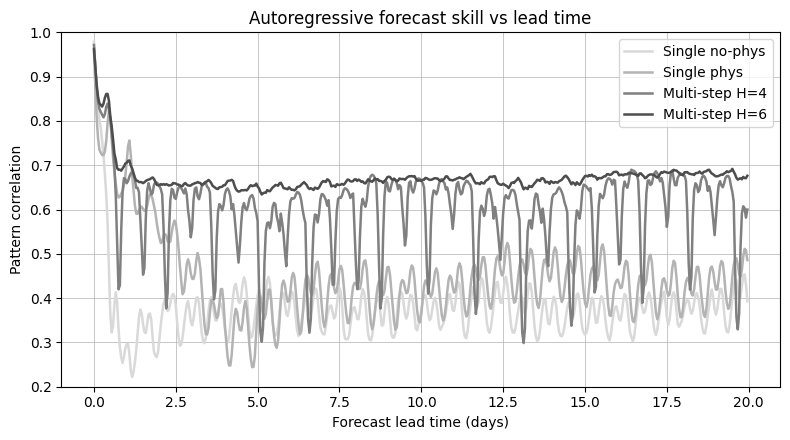


=== Summary statistics (normalized units) ===
            Model    Mode  H  Physics_weight  RMSE_norm  Bias_norm  \
0  Single no-phys  single  1             0.0     0.0668     0.0033   
1     Single phys  single  1             1.0     0.0867    -0.0012   
2  Multi-step H=4   multi  4             1.0     0.0766    -0.0038   
3  Multi-step H=6   multi  6             1.0     0.0844     0.0070   

   Global_corr  Mean_pattern_corr  Std_true_norm  Std_pred_norm  
0       0.9786             0.9790          0.324         0.3187  
1       0.9637             0.9641          0.324         0.3170  
2       0.9720             0.9729          0.324         0.3074  
3       0.9658             0.9664          0.324         0.3097  

Saved summary table to model_results_summary_selected.csv


In [7]:
# ============================================
# Step 8: Autoregressive forecast skill – selected models
# ============================================
def autoregressive_correlation(model, t_index, n_future_max):
    """
    Autoregressive rollout and pattern correlation vs lead time.
    Returns lead_days, corr_lead.

    Uses normalized fields directly.
    """
    model.eval()

    if t_index + n_future_max > forcing_tensor.shape[0]:
        n_future = forcing_tensor.shape[0] - t_index
        print(f"Adjusted n_future to {n_future} (data limit).")
    else:
        n_future = n_future_max

    with torch.no_grad():
        f_seq = forcing_tensor[t_index : t_index + n_future].unsqueeze(0)  # [1,T,2,H,W]
        p0    = prognostic_tensor[t_index].unsqueeze(0)                    # [1,1,H,W]
        pred_seq = model(
            f_seq, p0,
            training=False,
            num_future_steps=n_future
        )  # [T,1,H,W], normalized

    true_seq = target_tensor[t_index : t_index + n_future]   # [T,1,H,W], normalized

    corr_lead = []
    for k in range(n_future):
        t_field = true_seq[k].flatten()
        p_field = pred_seq[k].flatten()

        t_mean = t_field.mean()
        p_mean_loc = p_field.mean()
        num   = torch.sum((t_field - t_mean) * (p_field - p_mean_loc))
        denom = torch.sqrt(torch.sum((t_field - t_mean) ** 2) *
                           torch.sum((p_field - p_mean_loc) ** 2) + 1e-12)
        corr_lead.append((num / denom).item())

    corr_lead = np.array(corr_lead)

    lead_hours = np.arange(n_future)
    lead_days  = lead_hours / 24.0
    return lead_days, corr_lead


# Choose start time in TEST window and forecast horizon
t_index  = n_val   # first index of test region
n_future = 480     # ~20 days

# Only keep these four models
selected_names = [
    "Single no-phys",
    "Single phys",
    "Multi-step H=4",
    "Multi-step H=6",
]

# Greyscale colors: light → dark
color_map = {
    "Single no-phys": "#d9d9d9",  # light grey
    "Single phys":    "#b3b3b3",  # slightly darker
    "Multi-step H=4": "#808080",  # medium grey
    "Multi-step H=6": "#4d4d4d",  # dark grey
}

forecast_corr = {}
lead_days_ref = None

for name in selected_names:
    model = models[name]
    lead_days, corr_lead = autoregressive_correlation(model, t_index, n_future)
    forecast_corr[name] = corr_lead
    if lead_days_ref is None:
        lead_days_ref = lead_days

# --- Plot comparison: forecast skill vs lead time for 4 models ---
plt.figure(figsize=(8, 4.5))
for name in selected_names:
    plt.plot(
        lead_days_ref,
        forecast_corr[name],
        label=name,
        color=color_map[name],
        linewidth=1.8,
    )

plt.xlabel("Forecast lead time (days)")
plt.ylabel("Pattern correlation")
plt.ylim(0.2, 1.0)
plt.title("Autoregressive forecast skill vs lead time")
plt.grid(True, linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("forecast_pattern_correlation_selected_models.png")
plt.show()


# ============================================
# Step 9: Results table – selected models only
# ============================================
rows = []
for name in selected_names:
    m = metrics_all[name]

    # simple descriptors for table
    if "Multi-step" in name:
        mode = "multi"
        H_val = int(name.split("H=")[-1])
    else:
        mode = "single"
        H_val = 1

    if "no-phys" in name:
        phys_w = 0.0
    else:
        phys_w = 1.0

    rows.append({
        "Model": name,
        "Mode": mode,
        "H": H_val,
        "Physics_weight": phys_w,
        "RMSE_norm": m["rmse"],
        "Bias_norm": m["bias"],
        "Global_corr": m["global_corr"],
        "Mean_pattern_corr": m["mean_pattern_corr"],
        "Std_true_norm": m["std_true"],
        "Std_pred_norm": m["std_pred"],
    })

results_df = pd.DataFrame(rows)
print("\n=== Summary statistics (normalized units) ===")
print(results_df.round(4))

results_df.to_csv("model_results_summary_selected.csv", index=False)
print("\nSaved summary table to model_results_summary_selected.csv")


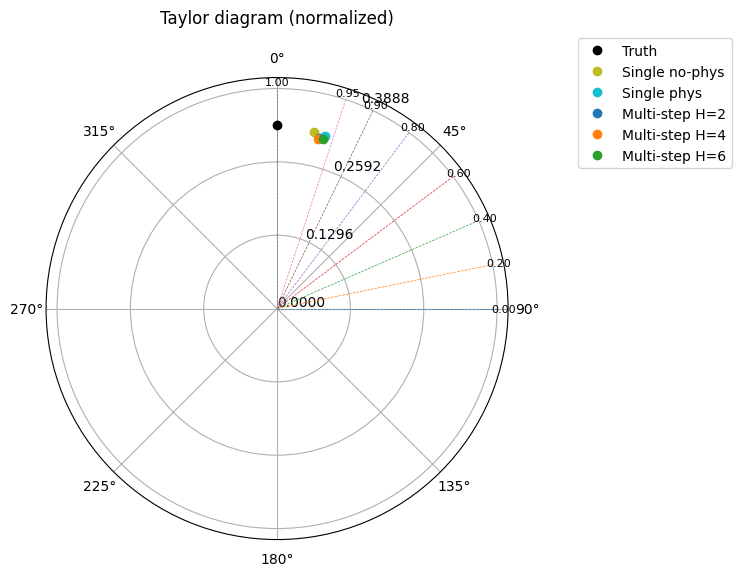

Saved Taylor diagram to taylor_diagram_all_models.png


In [4]:
# ============================================
# Step 10: Taylor diagram (optional, nice for paper)
# ============================================
def plot_taylor_diagram(stats_dict, fig_name=None):
    """
    Simple Taylor diagram.

    stats_dict: dict of name -> metrics dict
                each metrics must include 'std_true', 'std_pred', 'global_corr'
    """
    # assume std_true is the same for all, take from first
    first_key = next(iter(stats_dict.keys()))
    std_ref = stats_dict[first_key]["std_true"]

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)

    # polar settings: 0 deg at right, increase counterclockwise
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)

    # correlation gridlines
    corr_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
    r_max = 1.2 * max(
        std_ref,
        max(m["std_pred"] for m in stats_dict.values())
    )
    ax.set_rmax(r_max)
    ax.set_rticks(np.linspace(0, r_max, 4))

    for c in corr_ticks:
        theta = np.arccos(np.clip(c, -1.0, 1.0))
        ax.plot([theta, theta], [0, r_max], linestyle='--', linewidth=0.5)
        ax.text(theta, r_max * 1.03, f"{c:.2f}",
                ha='center', va='center', fontsize=8)

    # reference point (truth) at corr=1 (theta=0), radius=std_ref
    ax.plot(0, std_ref, 'ko', label="Truth")

    # models
    for name, m in stats_dict.items():
        c = np.clip(m["global_corr"], -1.0, 1.0)
        theta = np.arccos(c)
        r = m["std_pred"]
        ax.plot(theta, r, 'o', label=name)

    ax.set_title("Taylor diagram (normalized)", y=1.10)
    ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1))
    if fig_name is not None:
        plt.savefig(fig_name, bbox_inches='tight')
    plt.show()


plot_taylor_diagram(metrics_all, fig_name="taylor_diagram_all_models.png")
print("Saved Taylor diagram to taylor_diagram_all_models.png")